# OT in linear ICA

#### We already know that Fast ICA fails in a hybrid setup, but we also know that both OT ICA and Fast ICA fail for Binomial and Poisson, this notebook studies if this is due to jagged optimization surface for discrete distributions or due to the discrete distributions not being non gaussian enough?

In [1]:
import numpy as np
import torch
import pandas as pd
import time
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# Ensure wasserstein_ica.py is in your local directory
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Global Thesis Configuration & Helpers
# ==========================================
def set_thesis_theme():
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    plt.rcParams.update({
        'figure.figsize': (12, 6),
        'figure.dpi': 300,
        'axes.prop_cycle': plt.cycler(color=thesis_colors),
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.frameon': True,
        'legend.fontsize': 11,
        'lines.linewidth': 2.5
    })

def amari_error(W, A):
    if W is None or np.any(np.isnan(W)): return np.nan
    P = np.abs(np.dot(W, A))
    n = P.shape[0]
    row_sum = np.sum(P / np.max(P, axis=1, keepdims=True), axis=1) - 1.0
    col_sum = np.sum(P / np.max(P, axis=0, keepdims=True), axis=0) - 1.0
    return (np.sum(row_sum) + np.sum(col_sum)) / (2 * n)

set_thesis_theme()

In [3]:
# ==========================================
# 2. Unified Data Generators
# ==========================================
def generate_mixture(n_dim, n_samples, config_type, param=None, seed=None):
    if seed is not None: np.random.seed(seed)
    
    # Standard Generators
    def gen_laplace(): return np.random.laplace(0, 1/np.sqrt(2), size=n_samples)
    def gen_bernoulli(): return np.random.choice([-1.0, 1.0], size=n_samples)
    def gen_uniform(): return np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n_samples)
    def gen_student_t(): s = np.random.standard_t(df=3, size=n_samples); return s / np.std(s)
    
    # Parameterized Discrete Generators
    def gen_poisson(lam=3.0): s = np.random.poisson(lam=lam, size=n_samples); return (s - np.mean(s)) / np.std(s)
    def gen_binomial(n=10, p=0.5): s = np.random.binomial(n=n, p=p, size=n_samples); return (s - np.mean(s)) / np.std(s)
    
    # Positive continuous
    def gen_chisquare(): s = np.random.chisquare(df=2, size=n_samples); return (s - np.mean(s)) / np.std(s)
    def gen_exponential(): s = np.random.exponential(scale=1.0, size=n_samples); return (s - np.mean(s)) / np.std(s)

    pools = {
        'Full Hybrid': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, gen_poisson, gen_binomial, gen_chisquare, gen_exponential],
        'Continuous Only': [gen_laplace, gen_uniform, gen_student_t, gen_chisquare, gen_exponential],
        'Discrete Only': [gen_bernoulli, gen_poisson, gen_binomial],
        'Strictly Super-Gaussian': [gen_laplace, gen_student_t, gen_chisquare, gen_exponential],
        'Zero Gaussian': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, gen_poisson, gen_binomial, gen_chisquare, gen_exponential]
    }
    
    sources = []
    
    # Mode A: Ablation Pools
    if config_type in pools:
        active_pool = pools[config_type]
        if config_type != 'Zero Gaussian':
            sources.append(np.random.normal(0, 1, size=n_samples)) # Add Gaussian
            n_to_gen = n_dim - 1
        else:
            n_to_gen = n_dim
        for _ in range(n_to_gen): sources.append(np.random.choice(active_pool)())
            
    # Mode B: Single Isolated Discrete Type
    else:
        sources.append(np.random.normal(0, 1, size=n_samples)) # Baseline Gaussian
        for _ in range(n_dim - 1):
            if config_type == 'Bernoulli': sources.append(gen_bernoulli())
            elif config_type == 'Poisson': sources.append(gen_poisson(lam=param if param else 3.0))
            elif config_type == 'Binomial': sources.append(gen_binomial(n=param if param else 10))
            
    S = np.stack(sources)
    np.random.shuffle(S) # Hide the Gaussian
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
    return A @ S, A

In [4]:
# ==========================================
# 3. Unified Worker Function (UPDATED)
# ==========================================
def run_ica_trial(dim, trial, n_samples, config_type, method, param=None):
    torch.set_num_threads(1)
    X_np, A_true = generate_mixture(dim, n_samples, config_type, param, seed=trial)
    
    score = np.nan
    converged = False

    if method == 'FastICA':
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            try:
                # HIGH COMPUTE explicitly set to 10000 iterations
                fast_ica = FastICA(n_components=dim, max_iter=10000, tol=1e-4, random_state=trial)
                fast_ica.fit(X_np.T)
                score = amari_error(fast_ica.components_, A_true)
                if not any(isinstance(m.message, ConvergenceWarning) for m in w):
                    if not np.isnan(score) and score < 1.0: converged = True
            except Exception: pass

    elif method == 'OT-ICA':
        try:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            X_torch = torch.tensor(X_np, dtype=torch.float32).to(device)
            ica = WassersteinICA(X_torch)
            ica.whiten()
            W_white = ica.W_white.cpu().numpy()
            
            extracted = []
            n_restarts = min(dim * 4, 150)
            for _ in range(dim):
                prev = torch.stack(extracted) if extracted else None
                w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts, dither_sigma=0.01)
                extracted.append(w)
                
            W_stiefel = ica.optimize_symmetric(n_components=dim, max_iter=400, lr=0.25, init_w=torch.stack(extracted), optimizer='stiefel', dither_sigma=0.01, batch_size=1024)
            score = amari_error(W_stiefel.cpu().numpy() @ W_white, A_true)
            if not np.isnan(score) and score < 1.0: converged = True
        except Exception: pass

    # THE FIX IS HERE: Added 'Config_Param' to the dictionary output
    return {'Dim': dim, 'Config': config_type, 'Config_Param': param, 'Method': method, 'Error': score, 'Conv': int(converged)}

In [5]:
def plot_results(df, title, palette, x_col='Config'):
    # 1. Prepare Amari Error Data (Both Algorithms)
    df_plot = df.copy()
    # Apply a visual penalty for strictly failed/NaN runs so they appear on the chart
    df_plot['Error'] = df_plot['Error'].fillna(1.5) 

    # 2. Prepare Convergence Data (FastICA ONLY)
    # Mechanical convergence only makes sense for the fixed-point solver
    df_conv = df[df['Method'] == 'FastICA'].groupby(['Dim', x_col, 'Method'])['Conv'].mean().reset_index()
    df_conv['Success Rate (%)'] = df_conv['Conv'] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # --- Subplot 1: Amari Error (Both) ---
    sns.barplot(data=df_plot, x=x_col, y='Error', hue='Method', ax=ax1, palette=palette, edgecolor='black', errorbar='ci')
    ax1.set_title(f"Amari Error: {title}\n(Lower is Better)", fontsize=15)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right")
    #ax1.axhline(0.3, color='gray', linestyle=':', linewidth=2)
    #ax1.text(0, 0.32, 'Good Separation Threshold', color='gray', fontsize=11)
    ax1.set_ylim(0, 2.0) # Adjusted for better visual scaling

    # --- Subplot 2: Convergence Rate (FastICA Only) ---
    # We explicitly map the FastICA color to maintain consistency
    fast_palette = {'FastICA': palette['FastICA']}
    sns.barplot(data=df_conv, x=x_col, y='Success Rate (%)', hue='Method', ax=ax2, palette=fast_palette, edgecolor='black')
    ax2.set_title(f"Mechanical Convergence Rate: {title}\n(FastICA Only - Newton Solver Stability)", fontsize=15)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right")
    ax2.set_ylim(0, 105)

    plt.tight_layout()
    plt.show()
    
    # Display the numerical summary table
    display(df.groupby(['Method', x_col, 'Dim'])[['Error', 'Conv']].mean().round(4))

In [6]:
DIMENSIONS = [30, 40]
POOLS = ['Continuous Only', 'Discrete Only', 'Strictly Super-Gaussian', 'Zero Gaussian', 'Full Hybrid']
METHODS = ['FastICA', 'OT-ICA']
N_SAMPLES = 10000; N_TRIALS = 5 

print("--- Step 1: Sub-Pool Ablation Study ---")
tasks = [(dim, trial, N_SAMPLES, p, m, None) for dim in DIMENSIONS for p in POOLS for m in METHODS for trial in range(N_TRIALS)]
results_ablation = Parallel(n_jobs=8)(delayed(run_ica_trial)(*t) for t in tqdm(tasks))

df_ablation = pd.DataFrame(results_ablation)

--- Step 1: Sub-Pool Ablation Study ---


  0%|          | 0/100 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


/tmp/ipykernel_3226920/2366926203.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right")
/tmp/ipykernel_3226920/2366926203.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right")


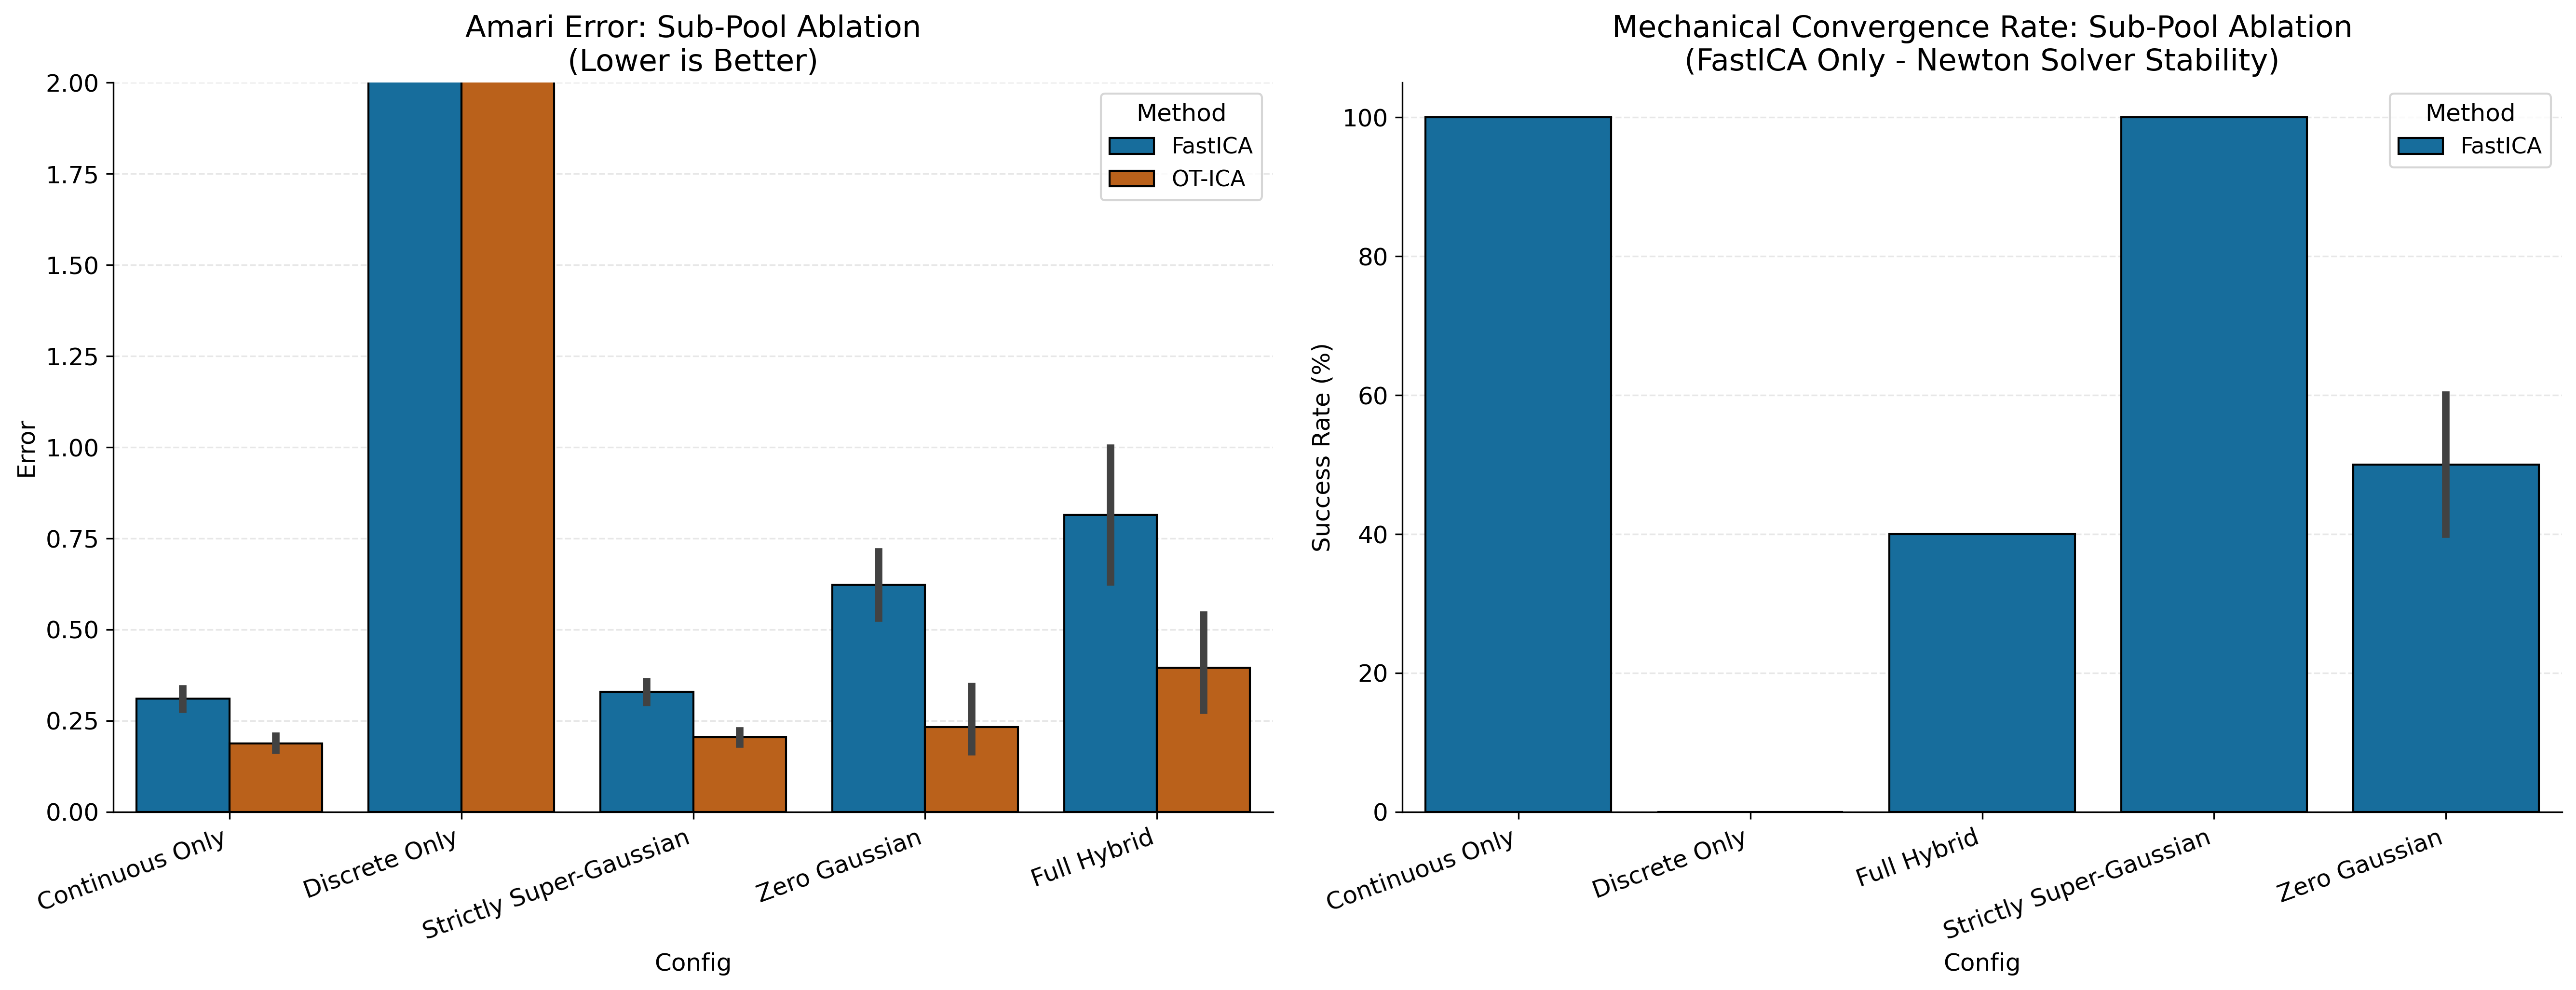

Error  Conv
Method  Config                  Dim              
FastICA Continuous Only         30   0.2672   1.0
                                40   0.3545   1.0
        Discrete Only           30   4.1976   0.0
                                40   5.8592   0.0
        Full Hybrid             30   0.7109   0.4
                                40   0.9199   0.4
        Strictly Super-Gaussian 30   0.2813   1.0
                                40   0.3764   1.0
        Zero Gaussian           30   0.5771   0.4
                                40   0.6688   0.6
OT-ICA  Continuous Only         30   0.1597   1.0
                                40   0.2165   1.0
        Discrete Only           30   4.2756   0.0
                                40   6.4532   0.0
        Full Hybrid             30   0.2398   1.0
                                40   0.5500   1.0
        Strictly Super-Gaussian 30   0.1760   1.0
                                40   0.2328   1.0
        Zero Gaussian           30   0.1525   1.0
                                40   0.3134   1.0

In [7]:
plot_results(df_ablation, "Sub-Pool Ablation", palette={'FastICA': '#0173B2', 'OT-ICA': '#D55E00'})

--- Step 2: Isolating Discrete Failure Modes ---


  0%|          | 0/60 [00:00<?, ?it/s]

/tmp/ipykernel_3226920/2366926203.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right")
/tmp/ipykernel_3226920/2366926203.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right")


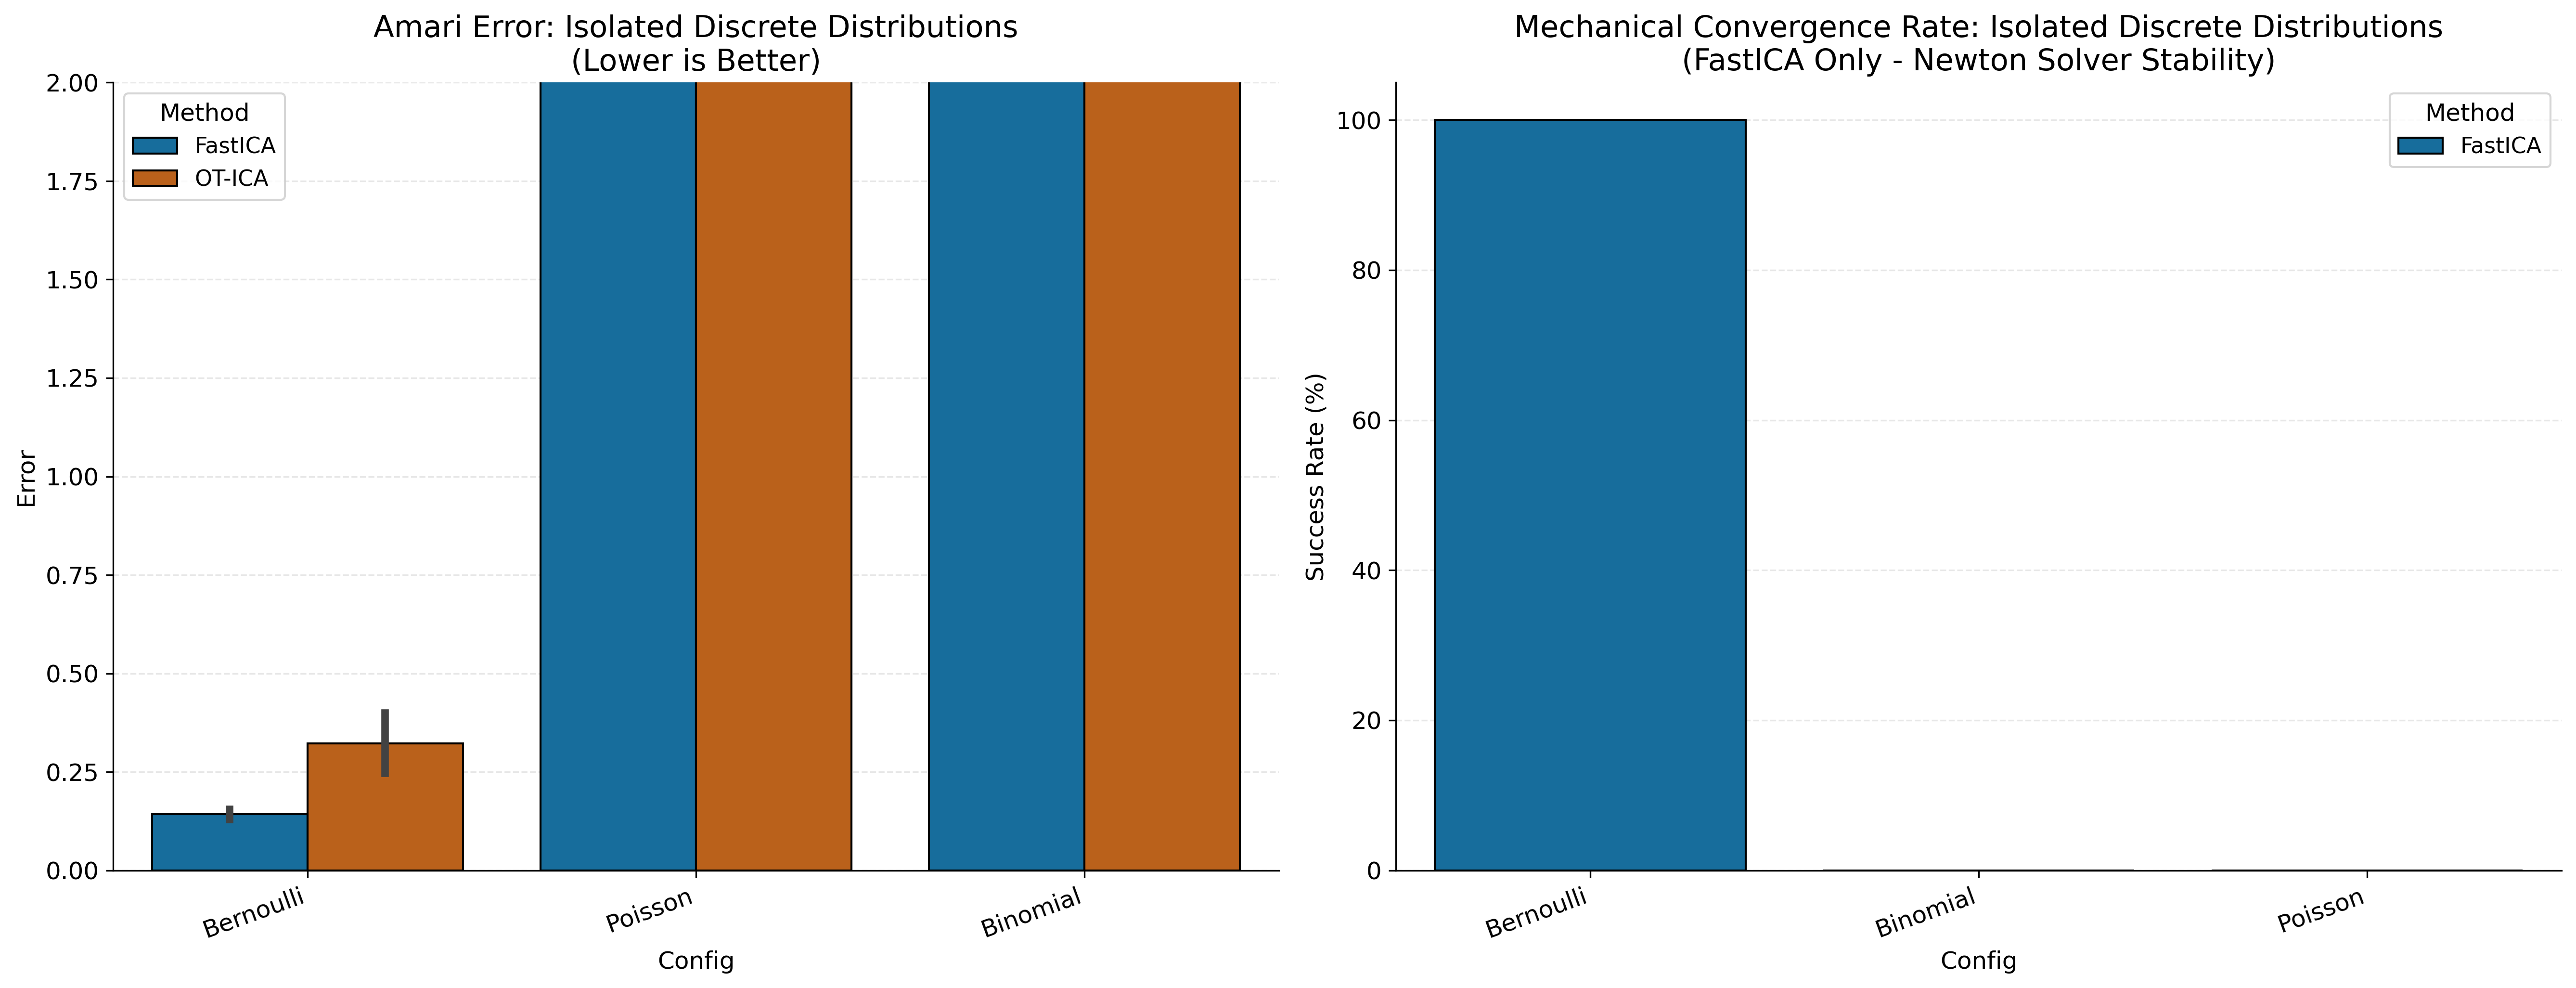

Error  Conv
Method  Config    Dim               
FastICA Bernoulli 30    0.1227   1.0
                  40    0.1620   1.0
        Binomial  30    8.4188   0.0
                  40   11.8596   0.0
        Poisson   30    8.0425   0.0
                  40   10.6933   0.0
OT-ICA  Bernoulli 30    0.2319   1.0
                  40    0.4124   1.0
        Binomial  30    9.2655   0.0
                  40   12.3299   0.0
        Poisson   30    3.5564   0.0
                  40    6.6619   0.0

In [8]:
DIST_TYPES = ['Bernoulli', 'Poisson', 'Binomial'] # Poisson is lam=3, Binomial is n=10

print("--- Step 2: Isolating Discrete Failure Modes ---")
tasks_disc = [(dim, trial, N_SAMPLES, d, m, None) for dim in DIMENSIONS for d in DIST_TYPES for m in METHODS for trial in range(N_TRIALS)]
results_discrete = Parallel(n_jobs=8)(delayed(run_ica_trial)(*t) for t in tqdm(tasks_disc))

df_discrete = pd.DataFrame(results_discrete)
plot_results(df_discrete, "Isolated Discrete Distributions", palette={'FastICA': '#0173B2', 'OT-ICA': '#D55E00'})

--- Step 3A: Non-Gaussianity Sensitivity Analysis (W2 Gap) ---
Distribution                   | W2 Sq Distance from Gaussian
-------------------------------------------------------
Poisson (Standard, λ=3.0)      | 0.051963
Poisson (Harsh, λ=0.5)         | 0.327711
Binomial (Standard, n=10)      | 0.033959
Binomial (Harsh, n=2)          | 0.202475
Laplace (Baseline)             | 0.037775

--- Step 3B: Optimization Surface Visualization ---


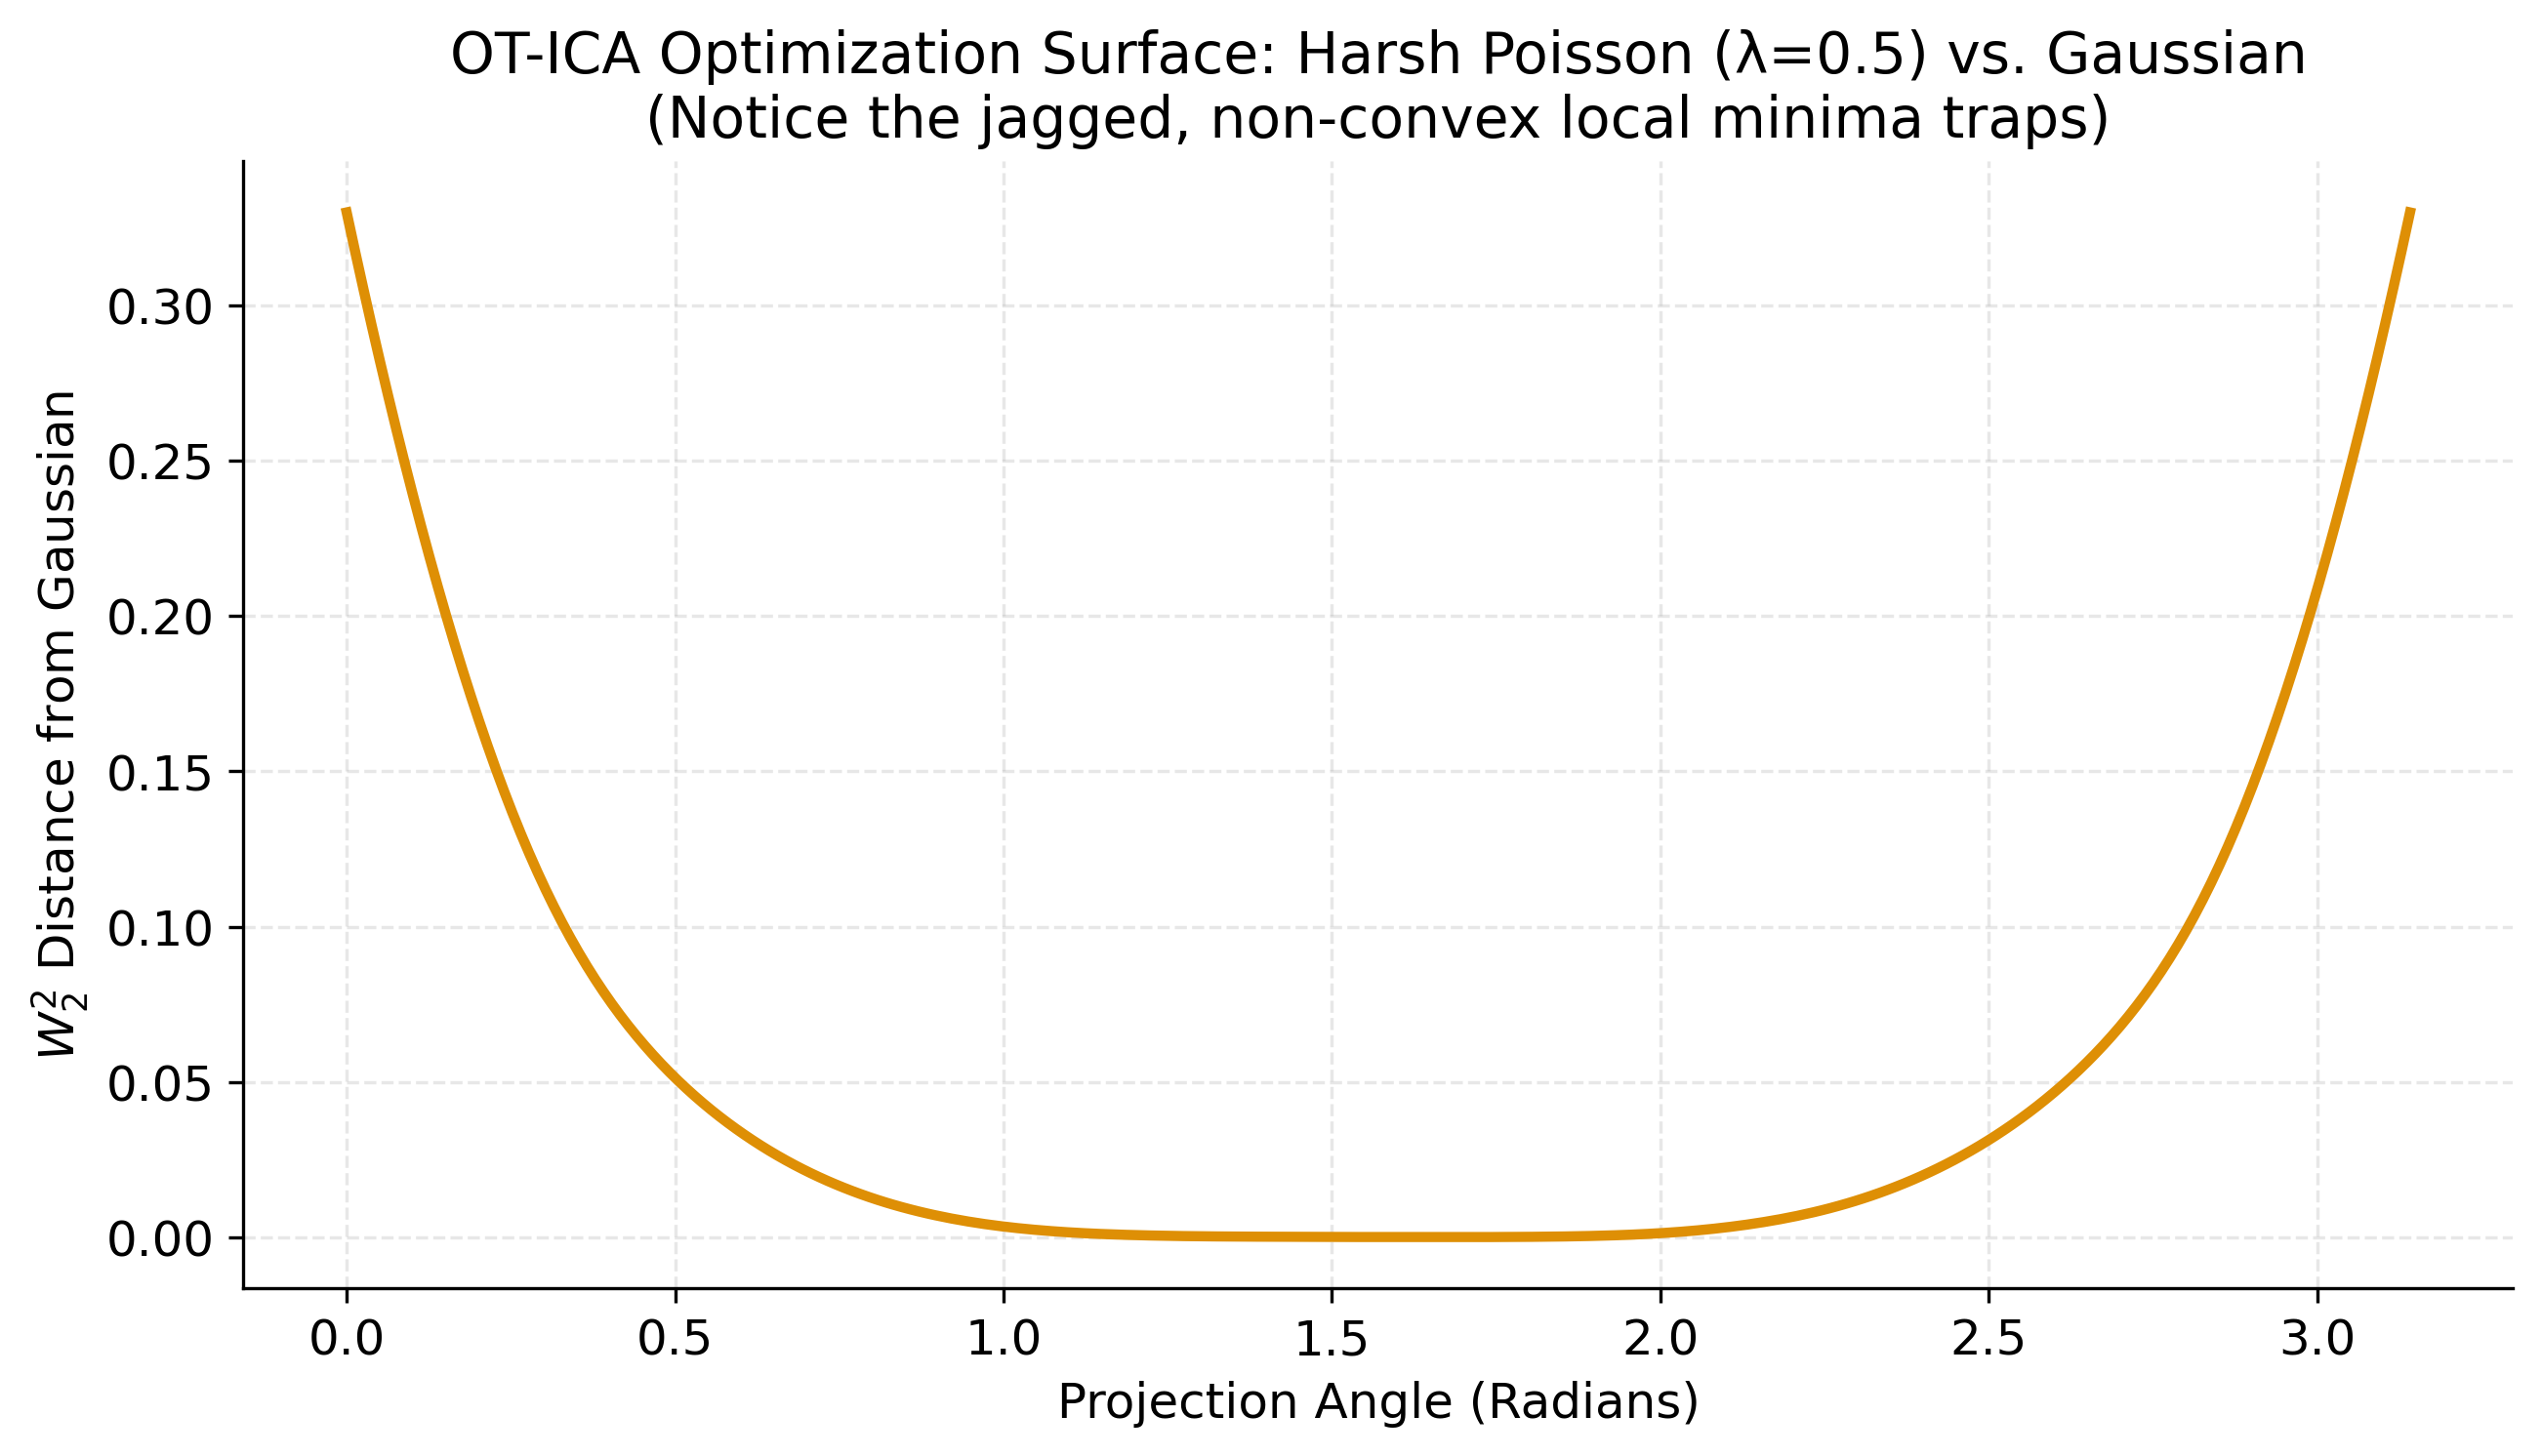

In [9]:
def get_analytical_gaussian_target(n_samples):
    p = torch.linspace(0, 1, n_samples + 2)[1:-1]
    return torch.distributions.Normal(0, 1).icdf(p)

print("--- Step 3A: Non-Gaussianity Sensitivity Analysis (W2 Gap) ---")
n_samples = 10000
target = get_analytical_gaussian_target(n_samples)

dists = {
    'Poisson (Standard, λ=3.0)': np.random.poisson(3.0, n_samples),
    'Poisson (Harsh, λ=0.5)': np.random.poisson(0.5, n_samples),
    'Binomial (Standard, n=10)': np.random.binomial(10, 0.5, n_samples),
    'Binomial (Harsh, n=2)': np.random.binomial(2, 0.5, n_samples),
    'Laplace (Baseline)': np.random.laplace(0, 1, n_samples)
}

print(f"{'Distribution':<30} | {'W2 Sq Distance from Gaussian':<20}")
print("-" * 55)
for name, samples in dists.items():
    s = (samples - samples.mean()) / samples.std() # Standardize
    sorted_s, _ = torch.sort(torch.tensor(s, dtype=torch.float32))
    w2_val = torch.mean((sorted_s - target)**2).item()
    print(f"{name:<30} | {w2_val:.6f}")

print("\n--- Step 3B: Optimization Surface Visualization ---")
# Mix Harsh Poisson (lambda=0.5) with Gaussian to show the non-convex staircase
lam = 0.5
s1 = np.random.poisson(lam, n_samples)
s1 = (s1 - s1.mean()) / s1.std()
s2 = np.random.normal(0, 1, n_samples)
S = np.vstack([s1, s2])

thetas = np.linspace(0, np.pi, 250)
w2_curve = []

for th in thetas:
    w = np.array([np.cos(th), np.sin(th)])
    y = w @ S
    y_std = (y - y.mean()) / y.std()
    y_torch = torch.sort(torch.tensor(y_std, dtype=torch.float32))[0]
    w2_curve.append(torch.mean((y_torch - target)**2).item())

plt.figure(figsize=(10, 5))
plt.plot(thetas, w2_curve, color='#DE8F05', linewidth=2.5)
plt.title(f"OT-ICA Optimization Surface: Harsh Poisson (λ={lam}) vs. Gaussian\n(Notice the jagged, non-convex local minima traps)", fontsize=14)
plt.ylabel('$W_2^2$ Distance from Gaussian', fontsize=12)
plt.xlabel('Projection Angle (Radians)', fontsize=12)
plt.show()

In [10]:
print("--- Step 4: Harsh Discrete Test (λ=0.5, n=3) ---")
# If it fails here, it proves the failure is due to geometric jaggedness, NOT a lack of non-Gaussianity!
HARSH_DIST = [('Poisson', 0.5), ('Binomial', 3)]

# Re-defining locally
DIMENSIONS = [30, 40]
N_SAMPLES = 10000
METHODS = ['FastICA', 'OT-ICA']
N_TRIALS = 5

tasks_harsh = [(dim, trial, N_SAMPLES, d, m, p) for dim in DIMENSIONS for (d, p) in HARSH_DIST for m in METHODS for trial in range(N_TRIALS)]
results_harsh = Parallel(n_jobs=8)(delayed(run_ica_trial)(*t) for t in tqdm(tasks_harsh))

df_harsh = pd.DataFrame(results_harsh)

# ==========================================
# BULLETPROOF FIX FOR JOBLIB CACHING BUG
# ==========================================
# If the background workers used the old function and dropped the key, 
# we manually reconstruct it from the original tasks list!
if 'Config_Param' not in df_harsh.columns:
    df_harsh['Config_Param'] = [task[5] for task in tasks_harsh]

# Safe string formatting that won't crash if a value is missing
df_harsh['Config'] = df_harsh.apply(
    lambda row: f"{row['Config']} (param={row['Config_Param']})" if pd.notna(row.get('Config_Param')) else row['Config'], 
    axis=1
)

--- Step 4: Harsh Discrete Test (λ=0.5, n=3) ---


  0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_3226920/2366926203.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right")
/tmp/ipykernel_3226920/2366926203.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right")


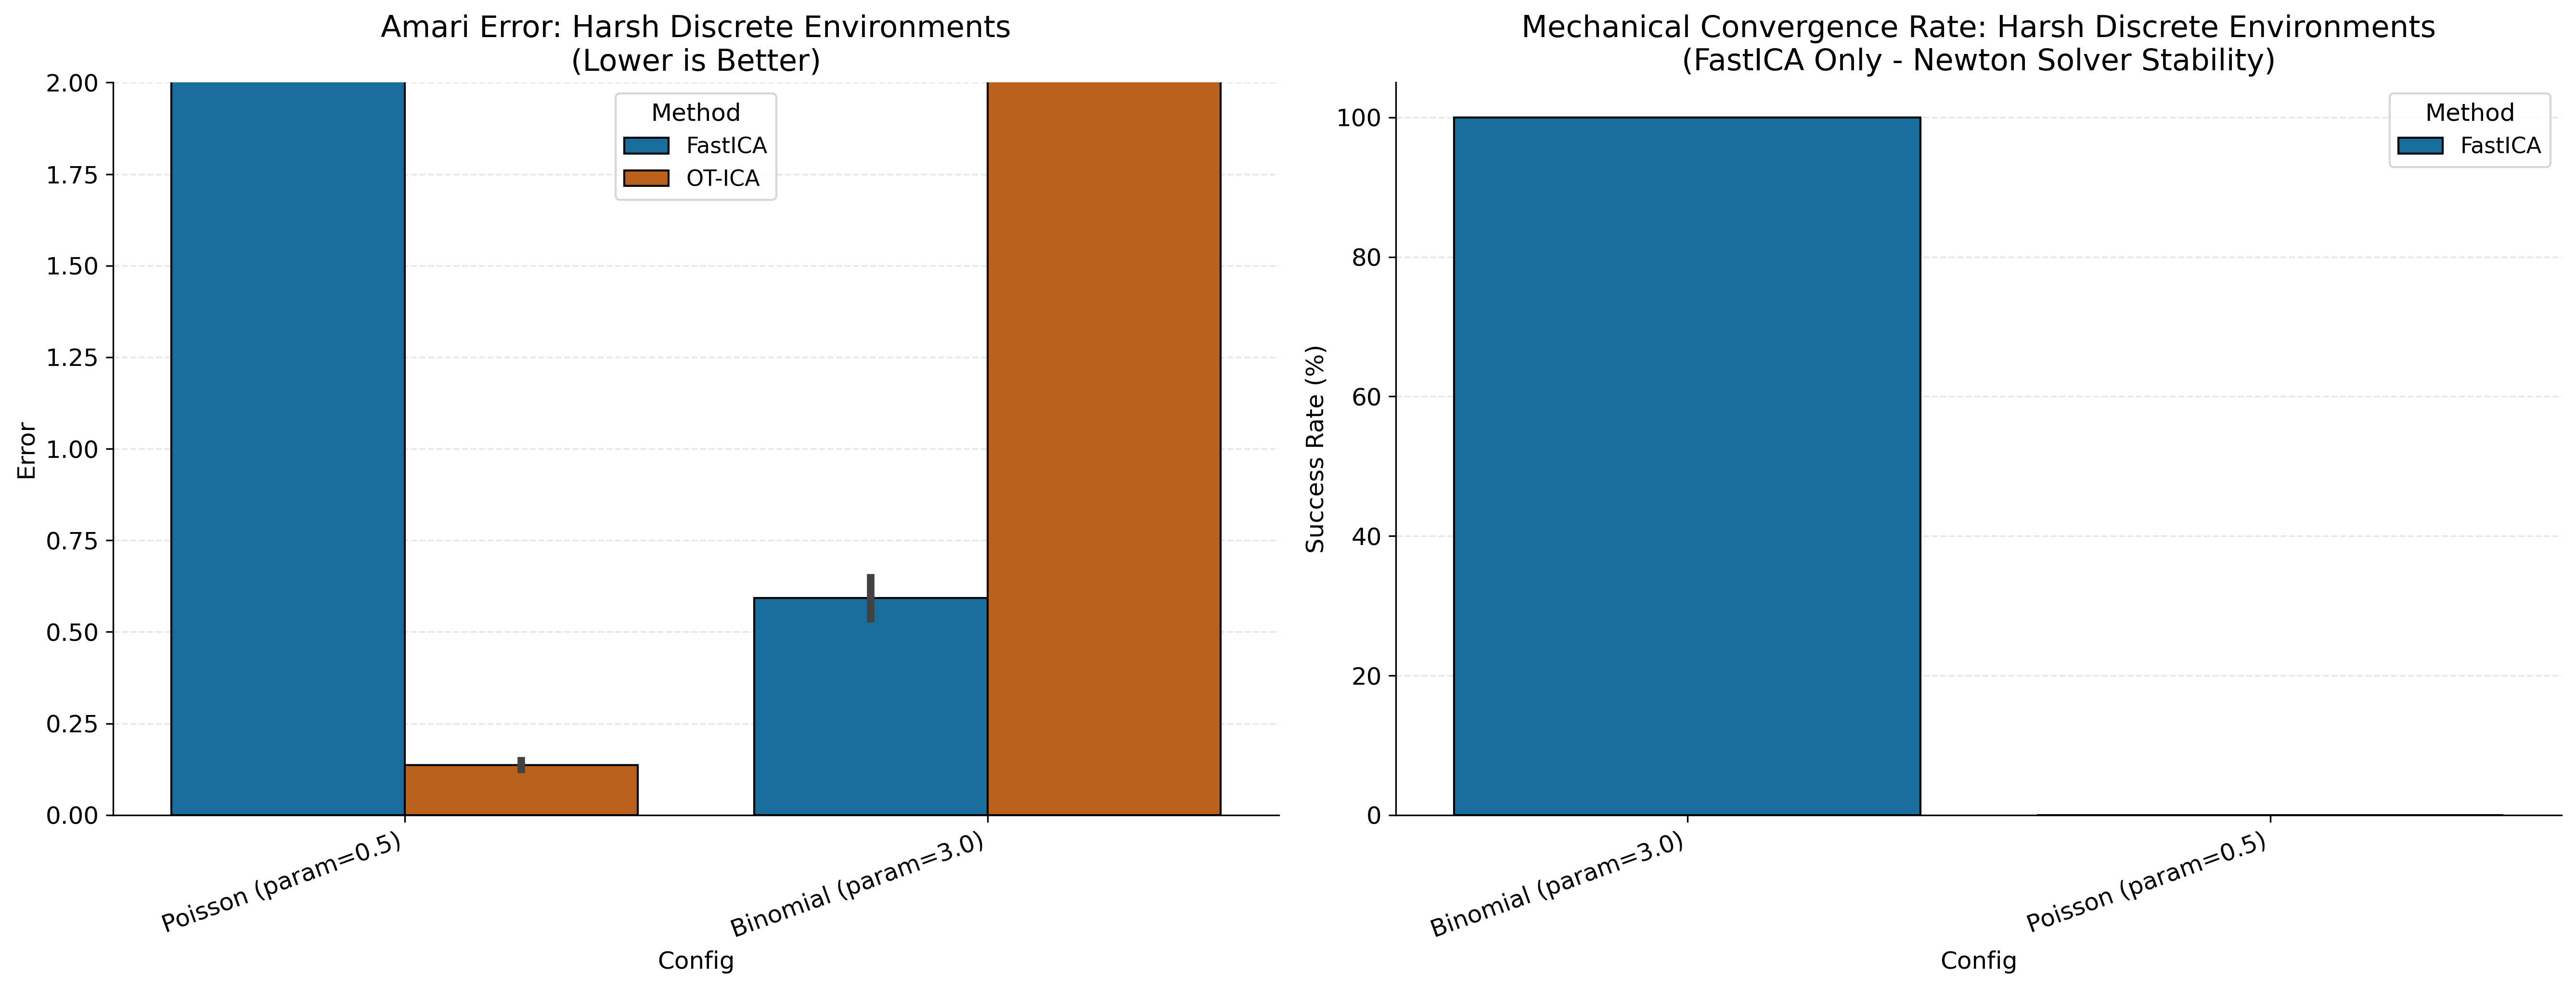

Error  Conv
Method  Config               Dim               
FastICA Binomial (param=3.0) 30    0.5008   1.0
                             40    0.6838   1.0
        Poisson (param=0.5)  30    2.0678   0.0
                             40    3.9071   0.0
OT-ICA  Binomial (param=3.0) 30    7.6563   0.0
                             40   11.3732   0.0
        Poisson (param=0.5)  30    0.1180   1.0
                             40    0.1550   1.0

In [11]:
plot_results(df_harsh, "Harsh Discrete Environments", palette={'FastICA': '#0173B2', 'OT-ICA': '#D55E00'})